# Required Imports

In [188]:
%pip install ucimlrepo


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [189]:
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

In [190]:
# Suppress warnings and messages
warnings.filterwarnings('ignore')
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

# Import Data

In [191]:
# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891) 
  
# data (as pandas dataframes) 
uci_df = pd.concat([cdc_diabetes_health_indicators.data.features, cdc_diabetes_health_indicators.data.targets], axis=1)
uci_df = uci_df.drop_duplicates()

# metadata 
print(cdc_diabetes_health_indicators.metadata) 
  
# variable information 
print(cdc_diabetes_health_indicators.variables) 

{'uci_id': 891, 'name': 'CDC Diabetes Health Indicators', 'repository_url': 'https://archive.ics.uci.edu/dataset/891/cdc+diabetes+health+indicators', 'data_url': 'https://archive.ics.uci.edu/static/public/891/data.csv', 'abstract': 'The Diabetes Health Indicators Dataset contains healthcare statistics and lifestyle survey information about people in general along with their diagnosis of diabetes. The 35 features consist of some demographics, lab test results, and answers to survey questions for each patient. The target variable for classification is whether a patient has diabetes, is pre-diabetic, or healthy. ', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Tabular', 'Multivariate'], 'num_instances': 253680, 'num_features': 21, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Sex', 'Age', 'Education Level', 'Income'], 'target_col': ['Diabetes_binary'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_

# Exploratory Data Analysis (EDA)

In [192]:
uci_df.head()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [193]:
# Target variable distribution
uci_df['Diabetes_binary'].value_counts()

Diabetes_binary
0    194377
1     35097
Name: count, dtype: int64

In [194]:
# Check for missing values
uci_df.isna().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

In [195]:
# Check duplicate rows
uci_df.duplicated().sum()

0

Text(0.5, 1.0, 'Increase in Diabetes Risk by Feature')

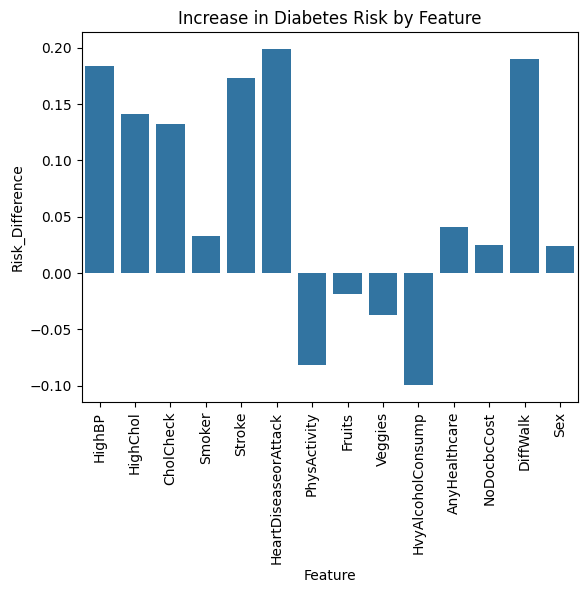

In [196]:
binary_cols = [row for row, type in zip(cdc_diabetes_health_indicators.variables.name, cdc_diabetes_health_indicators.variables.type) if type == 'Binary' and row != 'Diabetes_binary']

diffs = {
    col: uci_df.groupby(col)["Diabetes_binary"].mean().diff().iloc[-1]
    for col in binary_cols
}

plot_df = pd.Series(diffs).reset_index()
plot_df.columns = ["Feature","Risk_Difference"]

sns.barplot(data=plot_df, x="Feature", y="Risk_Difference")
plt.xticks(rotation=90)
plt.title("Increase in Diabetes Risk by Feature")

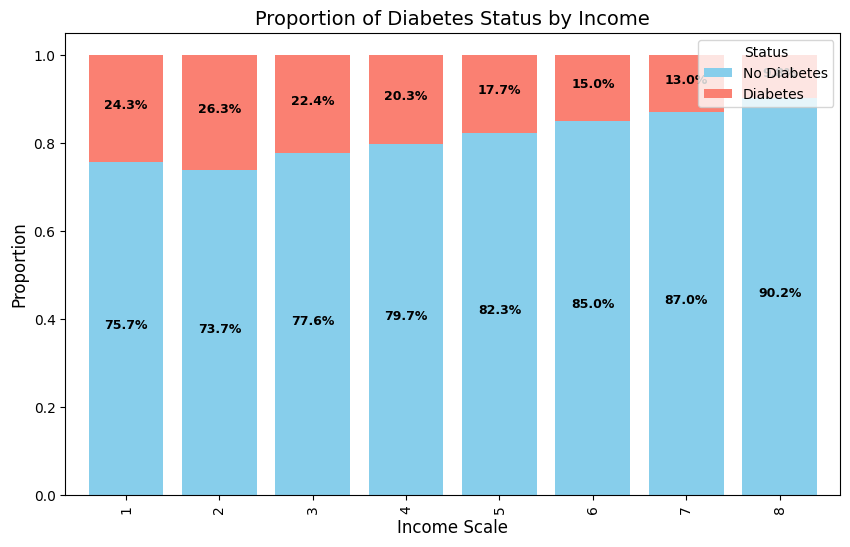

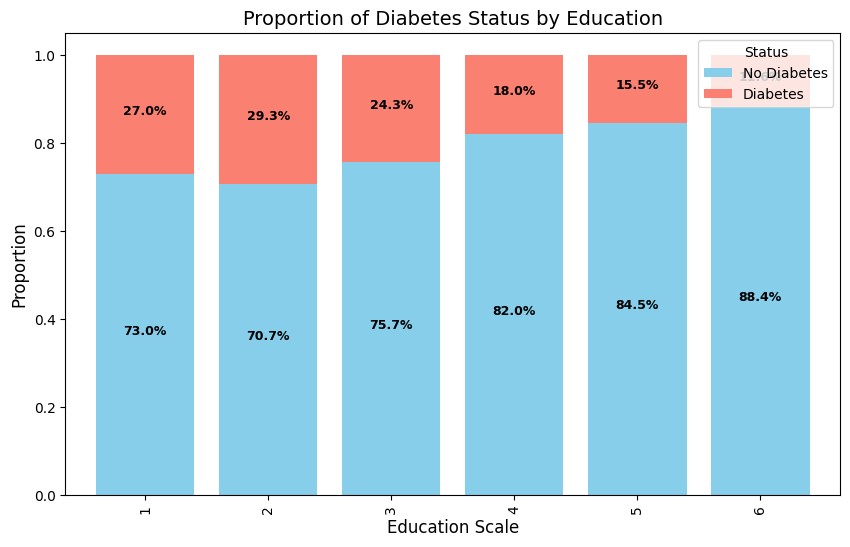

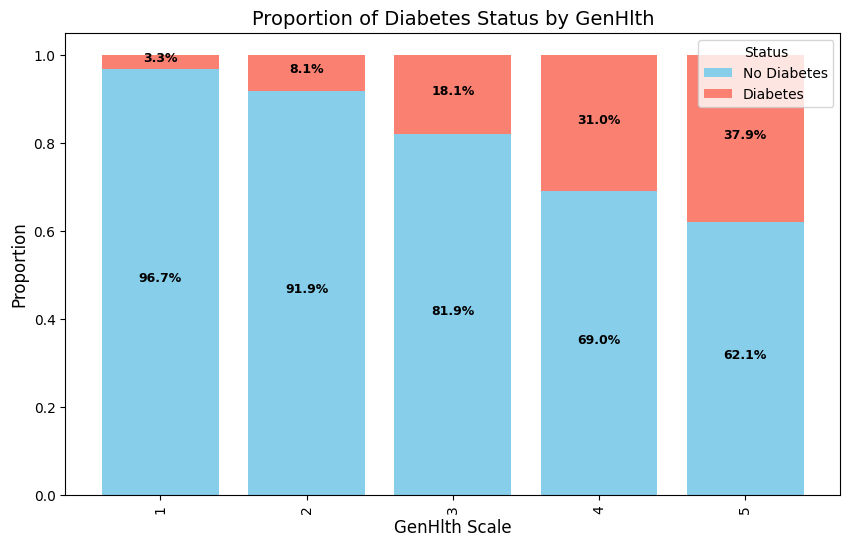

In [197]:
# Ordinal bar plots
ordinal_cols = ['Income', 'Education', 'GenHlth']
for col in ordinal_cols:
    cross_tab = pd.crosstab(uci_df[col], uci_df['Diabetes_binary'])
    
    cross_tab_prop = cross_tab.div(cross_tab.sum(1).astype(float), axis=0)
    
    ax = cross_tab_prop.plot(kind='bar', 
                             stacked=True, 
                             figsize=(10, 6), 
                             color=['skyblue', 'salmon'],
                             width=0.8)

    plt.title(f'Proportion of Diabetes Status by {col}', fontsize=14)
    plt.xlabel(f'{col} Scale', fontsize=12)
    plt.ylabel('Proportion', fontsize=12)
    plt.legend(title='Status', labels=['No Diabetes', 'Diabetes'], loc='upper right')
    
    for n, x in enumerate([*cross_tab_prop.index.values]):
        for (proportion, y_loc) in zip(cross_tab_prop.loc[x],
                                       cross_tab_prop.loc[x].cumsum()):
            plt.text(x=n,
                     y=(y_loc - proportion) + (proportion / 2),
                     s=f'{np.round(proportion * 100, 1)}%', 
                     color="black",
                     fontsize=9,
                     fontweight="bold",
                     ha="center")

    plt.show()

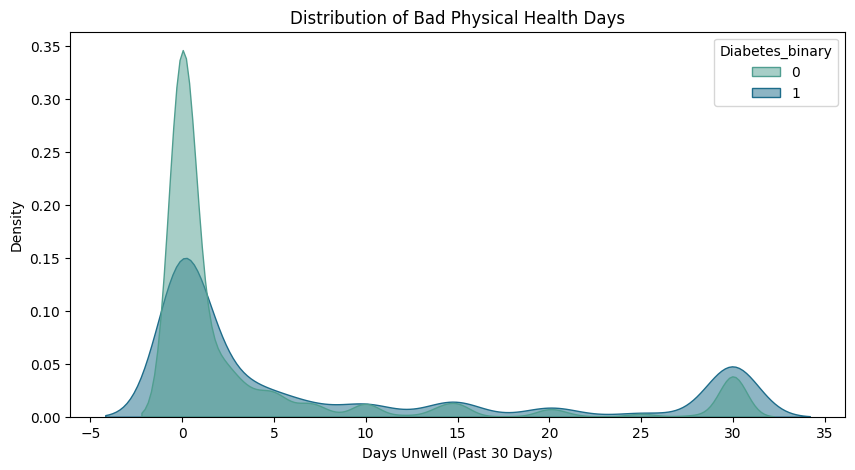

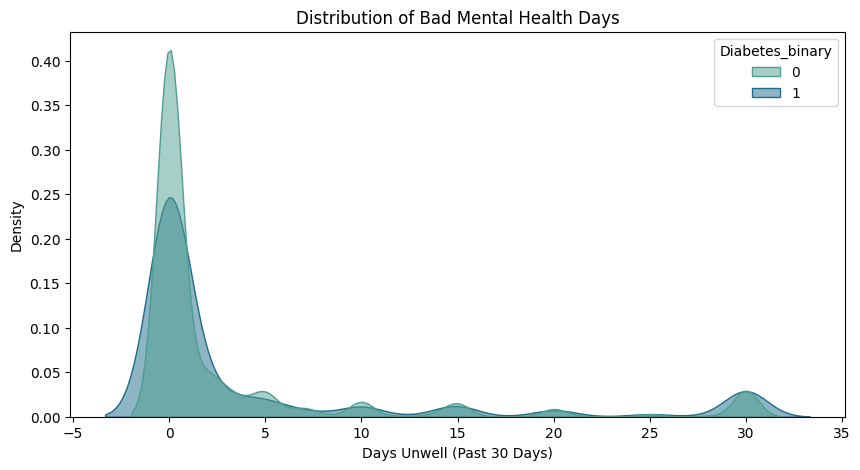

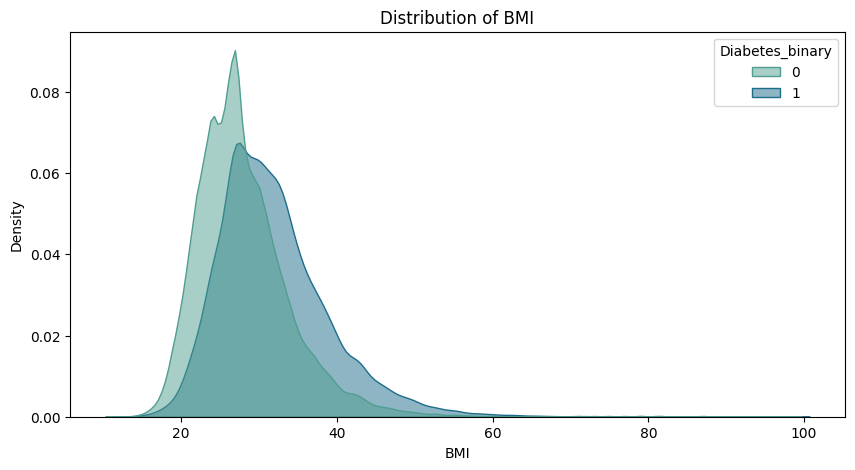

In [198]:
# Kernel Density Estimate (KDE) plots
plt.figure(figsize=(10, 5))
sns.kdeplot(data=uci_df, x='PhysHlth', hue='Diabetes_binary', 
            fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('Distribution of Bad Physical Health Days')
plt.xlabel('Days Unwell (Past 30 Days)')
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(data=uci_df, x='MentHlth', hue='Diabetes_binary', 
            fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('Distribution of Bad Mental Health Days')
plt.xlabel('Days Unwell (Past 30 Days)')
plt.show()

plt.figure(figsize=(10, 5))
sns.kdeplot(data=uci_df, x='BMI', hue='Diabetes_binary', 
            fill=True, common_norm=False, palette='crest', alpha=0.5)
plt.title('Distribution of BMI')
plt.xlabel('BMI')
plt.show()

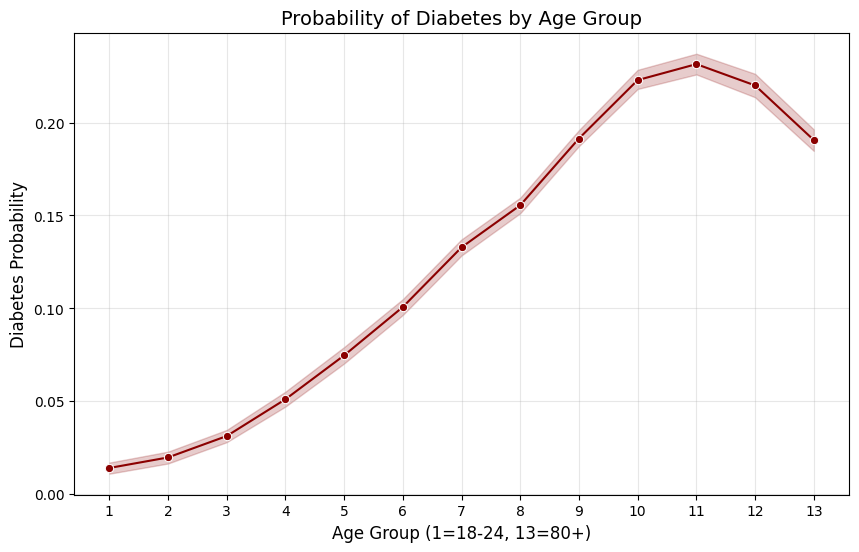

In [199]:
plt.figure(figsize=(10, 6))

# Plotting the mean of Diabetes_binary (which is the probability) for each Age bracket
sns.lineplot(x='Age', y='Diabetes_binary', data=uci_df, marker='o', color='darkred')

plt.title('Probability of Diabetes by Age Group', fontsize=14)
plt.xlabel('Age Group (1=18-24, 13=80+)', fontsize=12)
plt.ylabel('Diabetes Probability', fontsize=12)
plt.xticks(range(1, 14))
plt.grid(True, alpha=0.3)
plt.show()

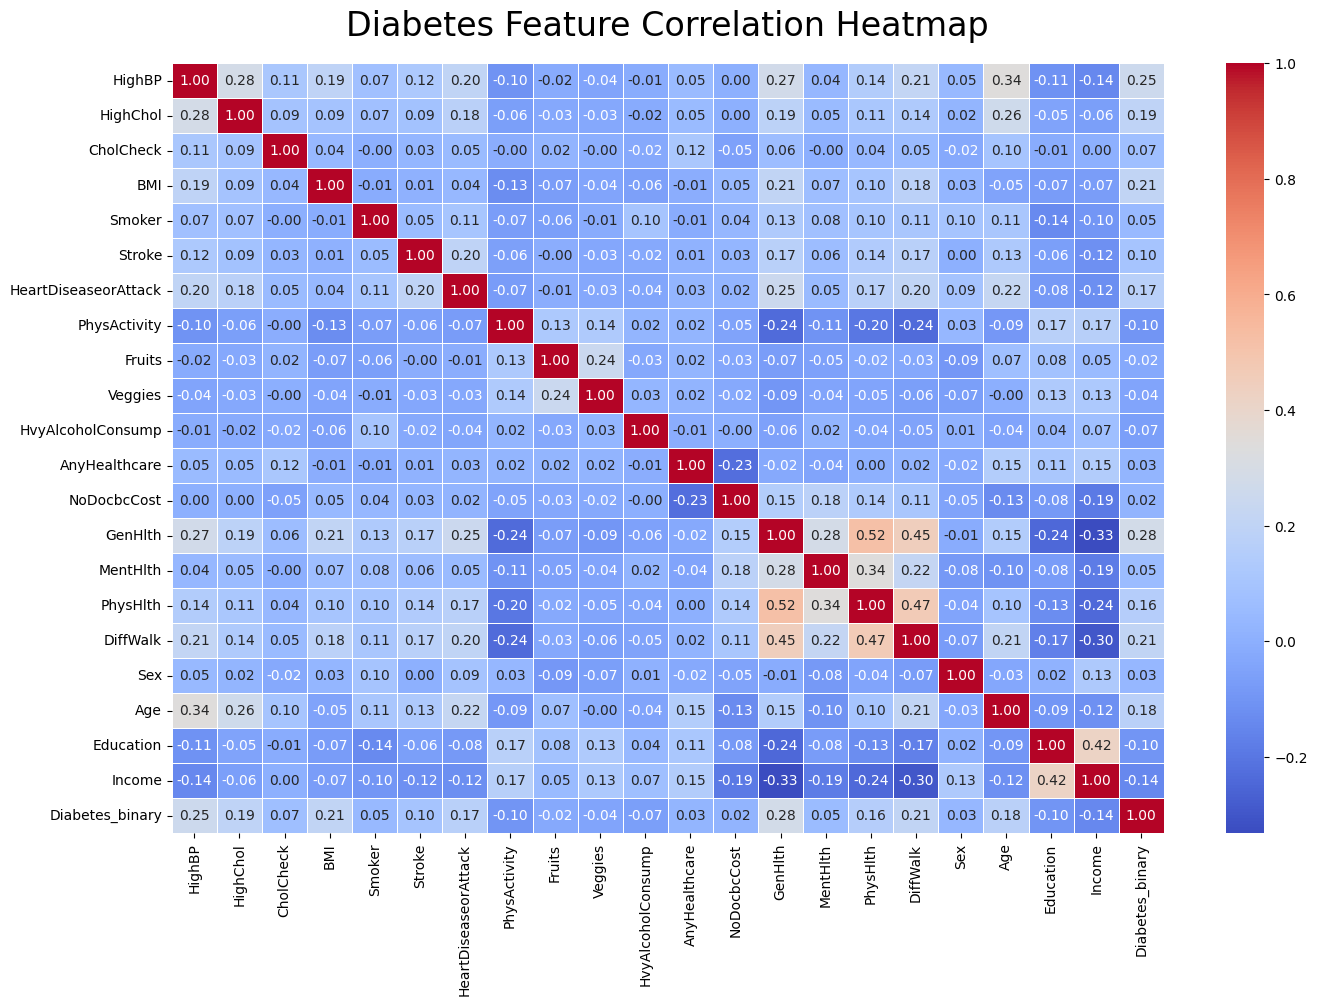

In [200]:
# Correlation heatmap
fig = plt.figure(figsize=(16, 10))
sns.heatmap(uci_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Diabetes Feature Correlation Heatmap", fontsize=24, pad=20)
plt.show()

# Data Preparation and Feature Engineering

In [201]:
# Total unhealthy days can be a strong indicator of overall health and diabetes risk
uci_df['Total_Unhealthy_Days'] = uci_df['MentHlth'] + uci_df['PhysHlth']

# A composite physical frailty score based on general health, difficulty walking, and physical health days
uci_df['Physical_Frailty'] = (((uci_df['GenHlth'] - 1) / 4) + uci_df['DiffWalk'] + (uci_df['PhysHlth'] / 30)) / 3

# Interaction between BMI and physical inactivity (not engaging in physical activity can exacerbate the effects of high BMI on diabetes risk)
uci_df['BMI_Inactive'] = uci_df['BMI'] * (1 - uci_df['PhysActivity'])

# A lifestyle risk score combining smoking, lack of healthcare access, and physical inactivity
uci_df['Lifestyle_Risk'] = (uci_df['Smoker'] + uci_df['NoDocbcCost'] + (1 - uci_df['PhysActivity']))

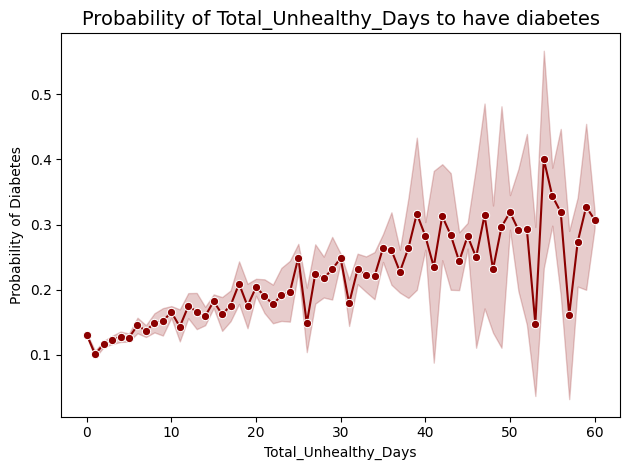

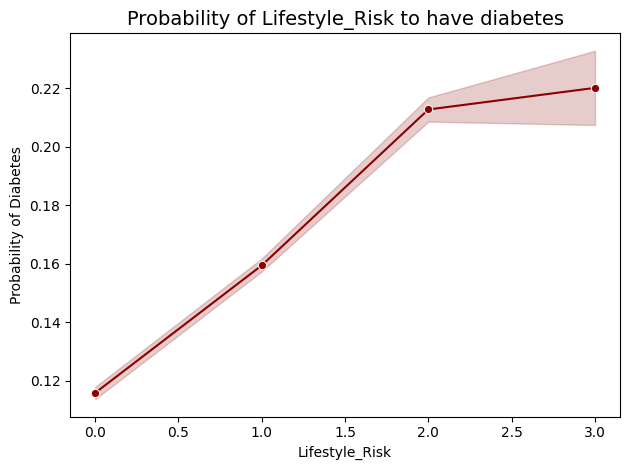

In [202]:
# Visualizing the relationship of these engineered features with diabetes probability
fig, axes = figsize=(18, 36)

columns = ['Total_Unhealthy_Days', 'Lifestyle_Risk']

for i, col in enumerate(columns):
    sns.lineplot(x=col, y='Diabetes_binary', data=uci_df, marker='o', color='darkred')
    plt.title(f'Probability of {col} to have diabetes', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Probability of Diabetes')

    plt.tight_layout()
    plt.show()

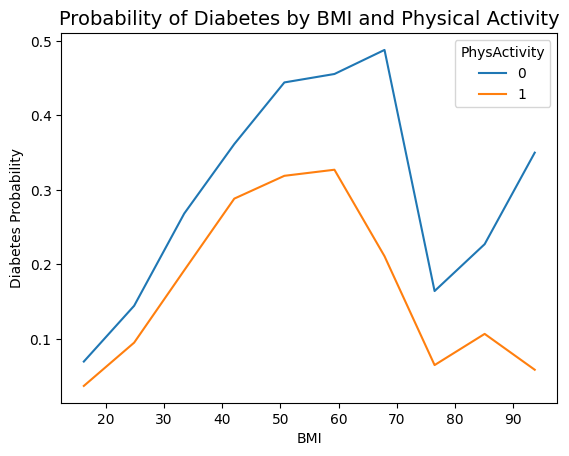

In [203]:
BMI_bin_df = uci_df.copy()
BMI_bin_df["BMI_bin"] = pd.cut(
    BMI_bin_df["BMI"],
    bins=10
)

line_data = (
    BMI_bin_df
    .groupby(["BMI_bin","PhysActivity"])["Diabetes_binary"]
    .mean()
    .reset_index()
)

line_data["bin_center"] = line_data["BMI_bin"].apply(lambda x: x.mid)

sns.lineplot(
    data=line_data,
    x="bin_center",
    y="Diabetes_binary",
    hue="PhysActivity"
)
plt.title('Probability of Diabetes by BMI and Physical Activity', fontsize=14)
plt.xlabel('BMI')
plt.ylabel('Diabetes Probability')
plt.show()

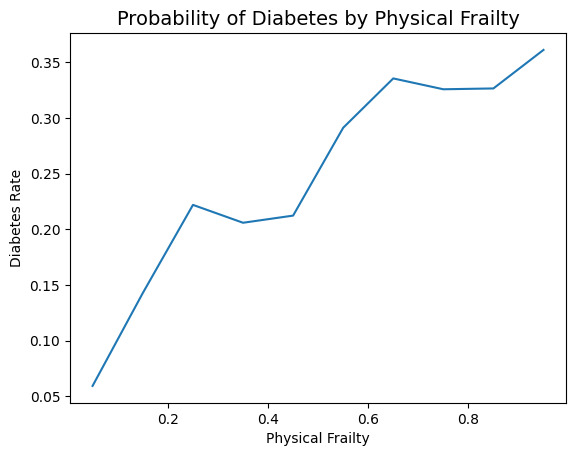

In [204]:
frailty = (
    uci_df
    .groupby(pd.cut(uci_df["Physical_Frailty"], bins=10))
    ["Diabetes_binary"]
    .mean()
    .reset_index()
)

frailty["mid"] = frailty["Physical_Frailty"].apply(lambda x: x.mid)

plt.plot(frailty["mid"], frailty["Diabetes_binary"])
plt.title('Probability of Diabetes by Physical Frailty', fontsize=14)
plt.xlabel("Physical Frailty")
plt.ylabel("Diabetes Rate")
plt.show()

In [205]:
uci_X = uci_df.drop('Diabetes_binary', axis=1)
uci_y = uci_df['Diabetes_binary']

In [206]:
# Standardize features for models sensitive to feature scaling
scaler = StandardScaler()
uci_X_scaled = scaler.fit_transform(uci_X)

In [207]:
uci_X_train, uci_X_test, uci_y_train, uci_y_test = train_test_split(uci_X_scaled, uci_y, test_size=0.2, stratify=uci_y, random_state=42)

# Baseline Model

In [208]:
lr = LogisticRegression()
lr.fit(uci_X_train, uci_y_train)

scores = cross_val_score(lr, uci_X_train, uci_y_train, cv=5, scoring="roc_auc")
print("CV ROC-AUC:", scores.mean())

CV ROC-AUC: 0.8061892155082451


In [209]:
lr_y_pred = lr.predict(uci_X_test)
print("Logistic Regression Classification Report:")
print(classification_report(uci_y_test, lr_y_pred))
print("Logistic Regression Confusion Matrix:")
print(confusion_matrix(uci_y_test, lr_y_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92     38876
           1       0.54      0.15      0.24      7019

    accuracy                           0.85     45895
   macro avg       0.70      0.57      0.58     45895
weighted avg       0.81      0.85      0.81     45895

Logistic Regression Confusion Matrix:
[[37955   921]
 [ 5940  1079]]
